# Functional Bayesian Networks

This notebook demonstrates how to work with Functional Bayesian Networks (FBNs) using pgmpy. It covers:
1. Defining a Functional BN
2. Simulating data from it
3. Fitting a functional BN
4. Prediction method is still under development (PR #1975) 

Functional BNs define the conditional distributions of each node in a functional form using the `FunctionalCPD` class. This provides a lot of functionality in terms of both variable types (combination of discrete, continuous variables) as well as the relationship between them (linear, non-linear, etc.)

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pgmpy.models import FunctionalBayesianNetwork
from pgmpy.factors.hybrid import FunctionalCPD
import torch
import pyro.distributions as dist
import pyro

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Defining a Functional Bayesian Network

Let's create a simple example: a student's performance model where:
- **Intelligence** (I): A discrete/categorical variable with `3` categories.
- **StudyHours** (S): A Gamma-distributed continuous variable.
- **Grade** (G): A conditional normal distribution conditioned on the parent variables `Intelligence` and `StudyHours`.
- **Recommendation** (R): A discrete/categorical variable with `2` categories. Has a conditional categorical distribution.

As with any BN, each node is parameterized using a conditional distribution over the node given its parents. In `FunctionalBayesianNetwork`, these conditional distributions are defined using `FunctionalCPD` objects.

### 1.1 Defining the network structure

The network structure can be defined by passing a list of edges in the network.

In [2]:
# Define the network structure
model = FunctionalBayesianNetwork([('Intelligence', 'Grade'), 
                                  ('StudyHours', 'Grade'),
                                  ('Grade', 'Recommendation')])

print("Functional Bayesian Network structure:")
print(f"Nodes: {list(model.nodes())}")
print(f"Edges: {list(model.edges())}")

Functional Bayesian Network structure:
Nodes: ['Intelligence', 'Grade', 'StudyHours', 'Recommendation']
Edges: [('Intelligence', 'Grade'), ('Grade', 'Recommendation'), ('StudyHours', 'Grade')]


### 1.2 Defining Conditional Distributions

To define `FunctionalCPDs` corresponding to each node, we need to first define the conditional distribution functions. These functions should:
1. Accept a `dict` called `parents`. `parents` can then be used within the function to access values of the parent variables of the node.
2. Return a `pyro.dist` object representing the conditional distribution given the parent values.

In [3]:
# Defining conditional distribution functions for the root nodes (i.e., no parents)
def intelligence_distribution(parents):
    """
    Assuming intelligence to be a categorical variable wiht categories: Low(0), Medium(1), High(2)
    """
    probs = pyro.param(
        "p_intelligence", 
        torch.tensor([0.3, 0.5, 0.2], dtype=torch.float),
        constraint=dist.constraints.simplex
    )
    return dist.Categorical(probs=probs)

def study_hours_distribution(parents):
    """
    Study hours as a continuous variable (0-12 hours per day)
    Uses the Gamma distribution to model study time
    """
    return dist.Gamma(2.0, 0.4)

# Using the conditional distrubtion functions to define the `FunctionalCPD` objects. 
cpd_intelligence = FunctionalCPD(
    variable='Intelligence',
    fn=intelligence_distribution
)

cpd_study = FunctionalCPD(
    variable='StudyHours',
    fn=study_hours_distribution,
)

print(f"Root node Functional CPDs defined: \n {cpd_intelligence} \n {cpd_study}")

Root node Functional CPDs defined: 
 P(Intelligence) = intelligence_distribution 
 P(StudyHours) = study_hours_distribution


In [4]:
# # Defining conditional distribution functions for the non-root nodes (i.e., have parents)

def compute_grade(parents):
    """
    Grade (0-100) with more controlled realistic relationships:
    - Intelligence provides base performance level
    - Study hours add improvement with diminishing returns
    - Reasonable variance for probabilistic outcomes
    """
    intelligence = parents["Intelligence"]
    study_hours = parents["StudyHours"]

    if not torch.is_tensor(intelligence):
        intelligence = torch.tensor(intelligence, dtype=torch.float)
    if not torch.is_tensor(study_hours):
        study_hours = torch.tensor(study_hours, dtype=torch.float)
    
    # More controlled base grades: Low=50, Average=65, High=75
    base_grade = 50.0 + intelligence * 12.5  # Low:50, Avg:62.5, High:75
    
    # Study hours with diminishing returns (capped at reasonable improvement)
    # Max 25 points improvement from studying
    study_effect = 25.0 * (1.0 - torch.exp(-study_hours / 4.0))
    
    # Final mean grade (ensure reasonable bounds)
    mean_grade = torch.clamp(base_grade + study_effect, 30.0, 95.0)
    
    # Smaller standard deviation for more predictable results
    std_grade = 8.0 - intelligence * 1.0  # Low:8, Avg:7, High:6
    
    return dist.Normal(mean_grade, std_grade)


# Create FunctionalCPD for Grade
cpd_grade = FunctionalCPD(
    variable='Grade',
    parents=['Intelligence', 'StudyHours'],
    fn=compute_grade,
)

print(f"Functional CPD for Grade: \n{cpd_grade}")

Functional CPD for Grade: 
P(Grade | Intelligence, StudyHours) = compute_grade


In [5]:
def compute_recommendation(parents):
    """
    Recommendation based on continuous grade with realistic thresholds
    Uses clear grade boundaries for interpretable results
    """
    grade = parents["Grade"]
    
    if not torch.is_tensor(grade):
        grade = torch.tensor(grade, dtype=torch.float)

    p_strong = torch.sigmoid((grade - 85.0) / 3.0)  # Sharp transition at 85
    p_conditional = torch.sigmoid((grade - 70.0) / 3.0) - p_strong  # Between 70-85
    p_none = 1.0 - p_strong - p_conditional  # Below 70
    
    # Ensure probabilities are valid
    p_none = torch.clamp(p_none, 0.0, 1.0)
    p_conditional = torch.clamp(p_conditional, 0.0, 1.0)
    p_strong = torch.clamp(p_strong, 0.0, 1.0)
    
    # Create probability vector and normalize
    probs = torch.stack([p_none, p_conditional, p_strong], dim=-1)
    probs = probs / (probs.sum(dim=-1, keepdim=True) + 1e-8)  # Add small epsilon
    
    return dist.Categorical(probs=probs)

# Create FunctionalCPD for Recommendation
cpd_recommendation = FunctionalCPD(
    variable='Recommendation',
    parents=['Grade'],
    fn=compute_recommendation,
)

print(f"Functional CPD for Recommendation: {cpd_recommendation}")

Functional CPD for Recommendation: P(Recommendation | Grade) = compute_recommendation


### 1.3 Add the `FunctionalCPD`s to `FunctionalBayesianNetwork`

In [6]:
# Add all CPDs to the model
model.add_cpds(cpd_intelligence, cpd_study, cpd_grade, cpd_recommendation)

# Verify the model
print(f"Is the model valid?: {model.check_model()} \n")
print(f"CPDs in model: ")
for cpd in model.get_cpds():
    print(cpd)

Is the model valid?: True 

CPDs in model: 
P(Intelligence) = intelligence_distribution
P(StudyHours) = study_hours_distribution
P(Grade | Intelligence, StudyHours) = compute_grade
P(Recommendation | Grade) = compute_recommendation


## 2. Simulating Data from the Functional BN

Now let's generate sample data from our functional Bayesian network to see how the deterministic relationships work.

In [7]:
samples = model.simulate(n_samples=1000, seed=42)

print("Generated 1000 samples from the Functional BN:")
print(samples.head(10))
print(f"\nDataset shape: {samples.shape}")
print(f"Columns: {list(samples.columns)}")

Generated 1000 samples from the Functional BN:
   Intelligence  StudyHours      Grade  Recommendation
0             1    2.864295  79.797699               1
1             0    1.247653  57.146500               0
2             2    9.977469  97.630768               2
3             1    2.610781  82.036987               1
4             2    2.848576  99.127220               2
5             1    5.470826  81.993431               1
6             2    3.129913  88.064713               2
7             1   14.145252  93.501015               2
8             1    1.648536  65.174561               0
9             0    2.836010  48.366383               0

Dataset shape: (1000, 4)
Columns: ['Intelligence', 'StudyHours', 'Grade', 'Recommendation']


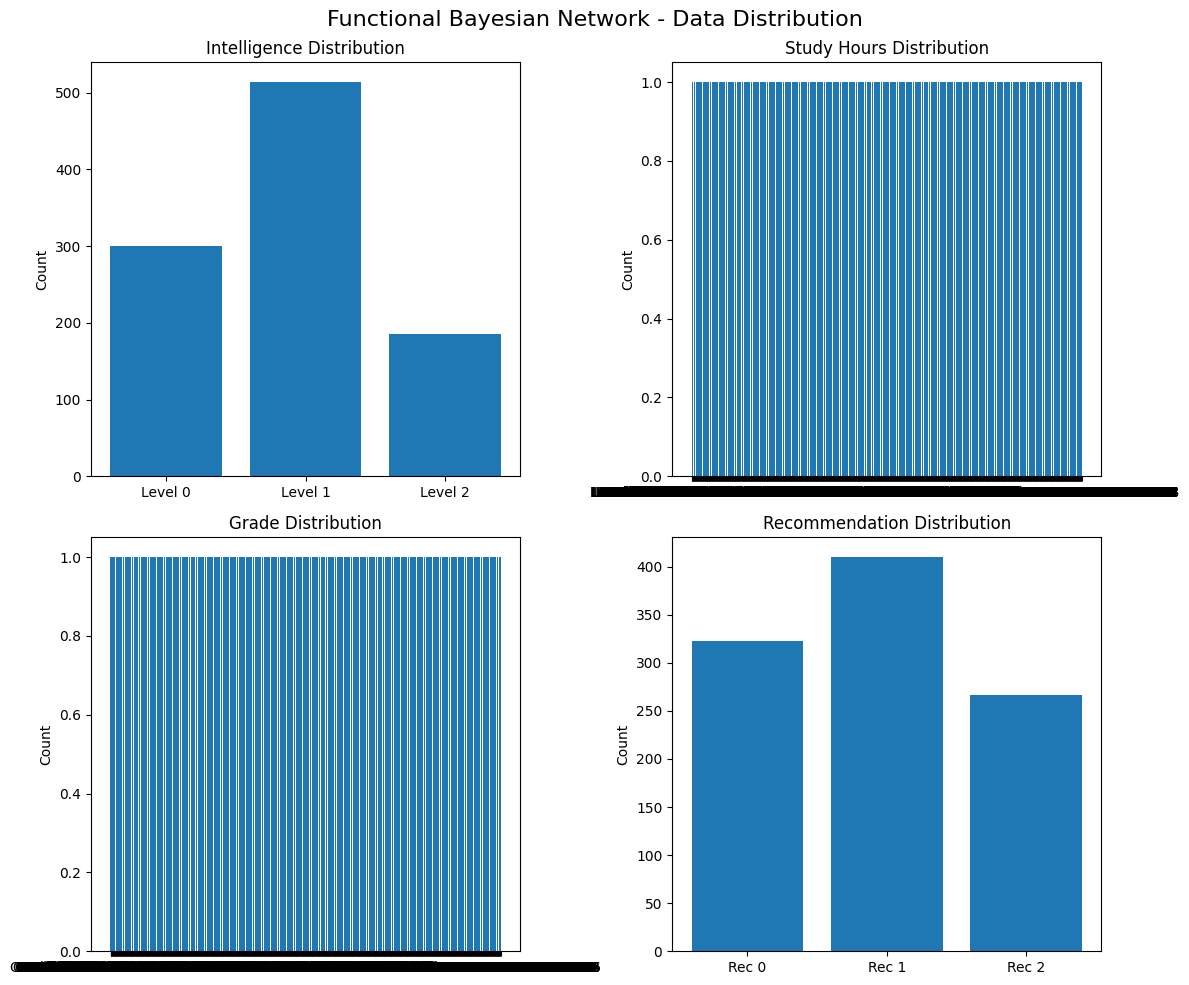

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Functional Bayesian Network - Data Distribution', fontsize=16)

# Intelligence distribution - handle variable number of categories
intelligence_counts = samples['Intelligence'].value_counts().sort_index()
intelligence_labels = [f'Level {i}' for i in intelligence_counts.index]
axes[0,0].bar(intelligence_labels, intelligence_counts.values)
axes[0,0].set_title('Intelligence Distribution')
axes[0,0].set_ylabel('Count')

# StudyHours distribution
study_counts = samples['StudyHours'].value_counts().sort_index()
study_labels = [f'Level {i}' for i in study_counts.index]
axes[0,1].bar(study_labels, study_counts.values)
axes[0,1].set_title('Study Hours Distribution')
axes[0,1].set_ylabel('Count')

# Grade distribution
grade_counts = samples['Grade'].value_counts().sort_index()
grade_labels = [f'Grade {i}' for i in grade_counts.index]
axes[1,0].bar(grade_labels, grade_counts.values)
axes[1,0].set_title('Grade Distribution')
axes[1,0].set_ylabel('Count')

# Recommendation distribution
rec_counts = samples['Recommendation'].value_counts().sort_index()
rec_labels = [f'Rec {i}' for i in rec_counts.index]
axes[1,1].bar(rec_labels, rec_counts.values)
axes[1,1].set_title('Recommendation Distribution')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Fitting a Functional BN from Data

Now let's demonstrate how to learn/fit a functional BN from observed data. We'll use the data we generated and try to recover the functional relationships.

In [9]:
params = model.fit(samples, method="SVI",
                   optimizer=pyro.optim.Adam({"lr": 0.05}),
                   seed=42, num_steps=100)
print(params)

INFO:pgmpy:Step 0 | Loss: 7333.7160
INFO:pgmpy:Step 50 | Loss: 7333.0227


{'p_intelligence': tensor([0.3000, 0.5141, 0.1859], grad_fn=<DivBackward0>)}


## 4. Making predictions from the Functional BN

Still in the works PR #1975